In [ ]:
# Session Starter
from google.colab import drive
drive.mount('/content/drive')

import os, json, cv2, numpy as np, random

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'

# Re-extract Eyes Defy Anemia
if not os.path.exists('/content/fresh_dataset/dataset anemia/Italy'):
    print("Extracting Eyes Defy Anemia...")
    !apt-get install -y p7zip-full -q
    !7z x /content/drive/MyDrive/anemia_project/dataset_clean.zip -o/content/fresh_dataset -y

# Re-download CP-AnemiC
if not os.path.exists('/content/cpanemic/extracted/Anemic'):
    print("Downloading CP-AnemiC...")
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({"username":"your_username","key":"your_key"}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !pip install kaggle -q
    !kaggle datasets download -d kritagyadev/cp-anemic-dataset-from-ghana -p /content/cpanemic
    import zipfile
    with zipfile.ZipFile('/content/cpanemic/cp-anemic-dataset-from-ghana.zip','r') as z:
        z.extractall('/content/cpanemic/extracted')

# Load split info
with open(os.path.join(DRIVE_PATH, 'split_info_combined.json'), 'r') as f:
    split_info = json.load(f)

train_paths  = split_info['train_paths']
val_paths    = split_info['val_paths']
test_paths   = split_info['test_paths']
train_labels = split_info['train_labels']
val_labels   = split_info['val_labels']
test_labels  = split_info['test_labels']

def preprocess(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.resize(img, (224, 224))
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    img = cv2.merge([l, a, b])
    img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
    return img.astype(np.float32) / 255.0

def augment(image):
    img = (image * 255).astype(np.uint8)
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
    angle = random.uniform(-20, 20)
    h, w  = img.shape[:2]
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img   = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    factor = random.uniform(0.75, 1.25)
    img    = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    return img.astype(np.float32) / 255.0

def save_img(img, folder, fname):
    img_uint8 = (img * 255).astype(np.uint8)
    cv2.imwrite(os.path.join(folder, fname),
                cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR))

# Rebuild folders
BASE_DIR = '/content/data'
for split in ['train', 'val', 'test']:
    for cls in ['anemic', 'normal']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

print("Rebuilding image folders...")
for i, (path, label) in enumerate(zip(train_paths, train_labels)):
    cls = 'anemic' if label == 1 else 'normal'
    img = preprocess(path)
    if img is None: continue
    save_img(img, os.path.join(BASE_DIR,'train',cls), f"{i:04d}_orig.png")
    for j in range(2):
        save_img(augment(img), os.path.join(BASE_DIR,'train',cls), f"{i:04d}_aug{j}.png")

for i, (path, label) in enumerate(zip(val_paths, val_labels)):
    cls = 'anemic' if label == 1 else 'normal'
    img = preprocess(path)
    if img is None: continue
    save_img(img, os.path.join(BASE_DIR,'val',cls), f"{i:04d}.png")

for i, (path, label) in enumerate(zip(test_paths, test_labels)):
    cls = 'anemic' if label == 1 else 'normal'
    img = preprocess(path)
    if img is None: continue
    save_img(img, os.path.join(BASE_DIR,'test',cls), f"{i:04d}.png")

train_total = sum(len(os.listdir(os.path.join(BASE_DIR,'train',c))) for c in ['anemic','normal'])
val_total   = sum(len(os.listdir(os.path.join(BASE_DIR,'val',c)))   for c in ['anemic','normal'])
test_total  = sum(len(os.listdir(os.path.join(BASE_DIR,'test',c)))  for c in ['anemic','normal'])

print(f"Italy  : {os.path.exists('/content/fresh_dataset/dataset anemia/Italy')}")
print(f"Ghana  : {os.path.exists('/content/cpanemic/extracted/Anemic')}")
print(f"Train  : {train_total} images")
print(f"Val    : {val_total} images")
print(f"Test   : {test_total} images")
print()


Mounted at /content/drive
Extracting Eyes Defy Anemia...
Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/anemia_project/                                                1 file, 666269625 bytes (636 MiB)

Extracting archive: /content/drive/MyDrive/anemia_project/dataset_clean.zip
--
Path = /content/drive/MyDrive/anemia_project/dataset_clean.zip
Type = zip
Physical Size = 666269625

  0%      1% 13 - dataset anemia/India/12/20200203_103722.jpg

In [ ]:
#  Data Generators
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

BASE_DIR   = '/content/data'
DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
models_dir = os.path.join(DRIVE_PATH, 'models')
os.makedirs(models_dir, exist_ok=True)

# Generators — rescale only, augmentation already done
datagen   = ImageDataGenerator(rescale=1.0/255.0)

train_gen = datagen.flow_from_directory(
    os.path.join(BASE_DIR,'train'), target_size=(224,224),
    batch_size=32, class_mode='binary', shuffle=True, seed=42)

val_gen   = datagen.flow_from_directory(
    os.path.join(BASE_DIR,'val'), target_size=(224,224),
    batch_size=32, class_mode='binary', shuffle=False)

test_gen  = datagen.flow_from_directory(
    os.path.join(BASE_DIR,'test'), target_size=(224,224),
    batch_size=32, class_mode='binary', shuffle=False)

# Class weights — nearly balanced now
anemic_n = len(os.listdir(os.path.join(BASE_DIR,'train','anemic')))
normal_n = len(os.listdir(os.path.join(BASE_DIR,'train','normal')))
class_weight = {0: normal_n/anemic_n, 1: 1.0}

print(f"Class indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"Class weights : {class_weight}")
print()
print("Generators ready!")

Found 1911 images belonging to 2 classes.
Found 136 images belonging to 2 classes.
Found 137 images belonging to 2 classes.
Class indices : {'anemic': 0, 'normal': 1}
Train batches : 60
Val batches   : 5
Test batches  : 5
Class weights : {0: 0.8252148997134671, 1: 1.0}

Generators ready!


In [ ]:
#  saves CP-AnemiC zip to Drive permanently
import os, shutil

src = '/content/cpanemic/cp-anemic-dataset-from-ghana.zip'
dst = '/content/drive/MyDrive/anemia_project/cpanemic_clean.zip'

if not os.path.exists(dst):
    print("Saving CP-AnemiC to Drive permanently...")
    shutil.copy2(src, dst)
    size = os.path.getsize(dst)/(1024*1024)
    print(f"Saved! Size: {size:.1f} MB")
else:
    print("Already saved on Drive!")

Saving CP-AnemiC to Drive permanently...
Saved! Size: 7.9 MB


In [ ]:
#  MobileNetV2 Transfer Learning
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load MobileNetV2
base_mobile = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_mobile.trainable = False

# Build head
x      = base_mobile.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs=base_mobile.input, outputs=output)
model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Total layers    : {len(model_mobile.layers)}")
print(f"Trainable       : {sum(1 for l in model_mobile.layers if l.trainable)}")
print(f"Frozen          : {sum(1 for l in model_mobile.layers if not l.trainable)}")
print()

callbacks_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(models_dir, 'mobilenet_combined_s1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Stage 1 — training head only...")
print("Takes 3-5 minutes...")
print()

history_s1 = model_mobile.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks_s1,
    class_weight=class_weight,
    verbose=1
)

print()
print(f"Stage 1 best val_accuracy: {max(history_s1.history['val_accuracy'])*100:.1f}%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layers    : 158
Trainable       : 4
Frozen          : 154

Stage 1 — training head only...
Takes 3-5 minutes...

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5734 - loss: 0.6576
Epoch 1: val_accuracy improved from None to 0.65441, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_s1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_s1.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.6206 - loss: 0.6011 - val_accuracy: 0.6544 - val_loss: 0.6231 - learning_rate: 0.0010
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7224 - loss: 0.4907
Epoch 2: val_accuracy improved from 0.65441 to 0.66912, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_s1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_s1.keras
60/60 ━━━━━━━━━━━━━━━━━━

In [ ]:
#  MobileNetV2 Stage 2 Fine-tuning
# Unfreeze last 30 layers and fine-tune

base_mobile.trainable = True
for layer in base_mobile.layers[:-30]:
    layer.trainable = False

# Recompile with very low lr
model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_now = sum(1 for l in model_mobile.layers if l.trainable)
print(f"Trainable layers (Stage 2): {trainable_now}")
print()

callbacks_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(models_dir, 'mobilenet_combined_final.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-8, verbose=1)
]

print("Stage 2 — fine-tuning last 30 layers...")
print("Takes 8-12 minutes...")
print()

history_s2 = model_mobile.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_s2,
    class_weight=class_weight,
    verbose=1
)

best_s2 = max(history_s2.history['val_accuracy'])
print()
print(f"Stage 1 best : 76.5%")
print(f"Stage 2 best : {best_s2*100:.1f}%")
print(f"Improvement  : +{(best_s2-0.765)*100:.1f}%")

Trainable layers (Stage 2): 34

Stage 2 — fine-tuning last 30 layers...
Takes 8-12 minutes...

Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6727 - loss: 0.5378
Epoch 1: val_accuracy improved from None to 0.68382, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_combined_final.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.6834 - loss: 0.5210 - val_accuracy: 0.6838 - val_loss: 0.5924 - learning_rate: 1.0000e-05
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7495 - loss: 0.4367
Epoch 2: val_accuracy did not improve from 0.68382
60/60 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7572 - loss: 0.4369 - val_accuracy: 0.6765 - val_loss: 0.6226 - learning_rate: 1.0000e-05
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7996 - loss: 0.3908
Epoch 3: val_accuracy did not improve from 0.68382
60/60 ━━━━

In [ ]:
#  FIXED MobileNetV2
import tensorflow as tf
import numpy as np
import cv2
import os
import json
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
models_dir = os.path.join(DRIVE_PATH, 'models')

# Load split info
with open(os.path.join(DRIVE_PATH, 'split_info_combined.json'), 'r') as f:
    split_info = json.load(f)

train_paths  = split_info['train_paths']
val_paths    = split_info['val_paths']
test_paths   = split_info['test_paths']
train_labels = split_info['train_labels']
val_labels   = split_info['val_labels']
test_labels  = split_info['test_labels']

# Custom data generator — CLAHE + MobileNetV2 preprocess_input
class AnemiaGenerator(Sequence):
    def __init__(self, paths, labels, batch_size=32,
                 augment=False, shuffle=True):
        self.paths      = paths
        self.labels     = np.array(labels)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            img = self._load(self.paths[i])
            if self.augment:
                img = self._augment(img)
            # MobileNetV2 preprocess_input — expects [0,255] uint8
            img_uint8 = (img * 255).astype(np.uint8)
            img_pre   = preprocess_input(img_uint8.astype(np.float32))
            X.append(img_pre)
            y.append(self.labels[i])
        return np.array(X), np.array(y)

    def _load(self, path):
        img = cv2.imread(path)
        if img is None:
            return np.zeros((224,224,3), dtype=np.float32)
        img = cv2.resize(img, (224,224))
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        img = cv2.merge([l, a, b])
        img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
        return img.astype(np.float32) / 255.0

    def _augment(self, img):
        import random
        img_u = (img * 255).astype(np.uint8)
        if random.random() > 0.5:
            img_u = cv2.flip(img_u, 1)
        angle = random.uniform(-20, 20)
        h, w  = img_u.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2,h//2), angle, 1.0)
        img_u = cv2.warpAffine(img_u, M, (w,h),
                               borderMode=cv2.BORDER_REFLECT)
        factor = random.uniform(0.8, 1.2)
        img_u  = np.clip(img_u.astype(np.float32)*factor,
                         0, 255).astype(np.uint8)
        return img_u.astype(np.float32) / 255.0

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create generators
train_gen2 = AnemiaGenerator(train_paths, train_labels,
                              batch_size=32, augment=True,  shuffle=True)
val_gen2   = AnemiaGenerator(val_paths,   val_labels,
                              batch_size=32, augment=False, shuffle=False)
test_gen2  = AnemiaGenerator(test_paths,  test_labels,
                              batch_size=32, augment=False, shuffle=False)

# Class weights
n_anemic = sum(train_labels)
n_normal = len(train_labels) - n_anemic
class_weight = {0: n_normal/n_anemic, 1: 1.0}

print(f"Train batches : {len(train_gen2)}")
print(f"Val batches   : {len(val_gen2)}")
print(f"Test batches  : {len(test_gen2)}")
print(f"Class weights : {class_weight}")
print()

# Build MobileNetV2 — Stage 1
tf.keras.backend.clear_session()

base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(224,224,3))
base.trainable = False

x      = base.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.4)(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_mobile2 = Model(inputs=base.input, outputs=output)
model_mobile2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum(1 for l in model_mobile2.layers if l.trainable)}")
print()

cb_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(models_dir,'mobilenet_v2_fixed_s1.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Stage 1 training — correct preprocessing...")
print()

h_s1 = model_mobile2.fit(
    train_gen2, epochs=15,
    validation_data=val_gen2,
    callbacks=cb_s1,
    class_weight=class_weight,
    verbose=1
)

print()
print(f"Stage 1 best val_accuracy: {max(h_s1.history['val_accuracy'])*100:.1f}%")

Train batches : 20
Val batches   : 5
Test batches  : 5
Class weights : {0: 0.8252148997134671, 1: 1.0}

Trainable layers: 6

Stage 1 training — correct preprocessing...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5266 - loss: 0.7327
Epoch 1: val_accuracy improved from None to 0.66176, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_v2_fixed_s1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_v2_fixed_s1.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5526 - loss: 0.7196 - val_accuracy: 0.6618 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5742 - loss: 0.6550
Epoch 2: val_accuracy did not improve from 0.66176
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5840 - loss: 0.6484 - val_accuracy: 0.5882 - val_loss: 0.6605 - learning_rate: 0.0010
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6128 - loss: 0.6058
Epoch 3: val_accuracy improved from 0.66176 to 0.69853, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_v2_fixed_s1.keras

Epoch 3: finished saving m

In [ ]:
# MobileNetV2 WITHOUT CLAHE
import tensorflow as tf
import numpy as np
import cv2, os, json, random
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
models_dir = os.path.join(DRIVE_PATH, 'models')

with open(os.path.join(DRIVE_PATH, 'split_info_combined.json'), 'r') as f:
    split_info = json.load(f)

train_paths  = split_info['train_paths']
val_paths    = split_info['val_paths']
test_paths   = split_info['test_paths']
train_labels = split_info['train_labels']
val_labels   = split_info['val_labels']
test_labels  = split_info['test_labels']

class AnemiaGenDL(Sequence):
    """Generator WITHOUT CLAHE — standard preprocessing for DL models"""
    def __init__(self, paths, labels, batch_size=32,
                 augment=False, shuffle=True):
        self.paths      = list(paths)
        self.labels     = np.array(labels)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            img = self._load(self.paths[i])
            if self.augment:
                img = self._augment(img)
            img_pre = preprocess_input(img.astype(np.float32))
            X.append(img_pre)
            y.append(self.labels[i])
        return np.array(X), np.array(y)

    def _load(self, path):
        img = cv2.imread(path)
        if img is None:
            return np.zeros((224,224,3), dtype=np.float32)
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img.astype(np.float32)

    def _augment(self, img):
        img_u = img.astype(np.uint8)
        if random.random() > 0.5:
            img_u = cv2.flip(img_u, 1)
        angle = random.uniform(-20, 20)
        h, w  = img_u.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2,h//2), angle, 1.0)
        img_u = cv2.warpAffine(img_u, M, (w,h),
                               borderMode=cv2.BORDER_REFLECT)
        factor = random.uniform(0.8, 1.2)
        img_u  = np.clip(img_u.astype(np.float32)*factor,
                         0, 255).astype(np.uint8)
        return img_u.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create generators
train_gen3 = AnemiaGenDL(train_paths, train_labels,
                          batch_size=32, augment=True, shuffle=True)
val_gen3   = AnemiaGenDL(val_paths,   val_labels,
                          batch_size=32, augment=False, shuffle=False)
test_gen3  = AnemiaGenDL(test_paths,  test_labels,
                          batch_size=32, augment=False, shuffle=False)

n_anemic     = sum(train_labels)
n_normal     = len(train_labels) - n_anemic
class_weight = {0: n_normal/n_anemic, 1: 1.0}

print(f"Train batches : {len(train_gen3)}")
print(f"Val batches   : {len(val_gen3)}")
print(f"Class weights : {class_weight}")
print()

# Build MobileNetV2
tf.keras.backend.clear_session()

base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(224,224,3))
base.trainable = False

x      = base.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.4)(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_m = Model(inputs=base.input, outputs=output)
model_m.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable: {sum(1 for l in model_m.layers if l.trainable)}")
print()

cb_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(models_dir,'mobilenet_noclahe_s1.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Stage 1 — MobileNetV2 without CLAHE...")
print("CLAHE is for ML features only, not for pretrained DL models")
print()

h_s1 = model_m.fit(
    train_gen3, epochs=15,
    validation_data=val_gen3,
    callbacks=cb_s1,
    class_weight=class_weight,
    verbose=1
)

print()
print(f"Stage 1 best val_accuracy: {max(h_s1.history['val_accuracy'])*100:.1f}%")

Train batches : 20
Val batches   : 5
Class weights : {0: 0.8252148997134671, 1: 1.0}

Trainable: 6

Stage 1 — MobileNetV2 without CLAHE...
CLAHE is for ML features only, not for pretrained DL models

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5178 - loss: 0.8109
Epoch 1: val_accuracy improved from None to 0.61029, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_s1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_s1.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5369 - loss: 0.7719 - val_accuracy: 0.6103 - val_loss: 0.6596 - learning_rate: 0.0010
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5427 - loss: 0.6743
Epoch 2: val_accuracy improved from 0.61029 to 0.62500, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_s1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_s1.ke

In [ ]:
#  MobileNetV2 Stage 2 Fine-tuning
# Unfreeze last 50 layers — more than before since dataset is larger now

base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False

model_m.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers Stage 2: {sum(1 for l in model_m.layers if l.trainable)}")
print()

cb_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(models_dir, 'mobilenet_noclahe_final.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-8, verbose=1)
]

print("Stage 2 — fine-tuning last 50 layers...")
print("More layers unfrozen because dataset is now 910 images")
print()

h_s2 = model_m.fit(
    train_gen3, epochs=30,
    validation_data=val_gen3,
    callbacks=cb_s2,
    class_weight=class_weight,
    verbose=1
)

best_s2 = max(h_s2.history['val_accuracy'])
print()
print(f"Stage 1 best : 73.5%")
print(f"Stage 2 best : {best_s2*100:.1f}%")

Trainable layers Stage 2: 56

Stage 2 — fine-tuning last 50 layers...
More layers unfrozen because dataset is now 910 images

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6232 - loss: 0.5817
Epoch 1: val_accuracy improved from None to 0.72794, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_final.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.6279 - loss: 0.5814 - val_accuracy: 0.7279 - val_loss: 0.5406 - learning_rate: 1.0000e-05
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6974 - loss: 0.5280
Epoch 2: val_accuracy improved from 0.72794 to 0.74265, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_noclahe_final.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.6

In [ ]:

# Train MobileNetV2 on CP-AnemiC ONLY first
# CP-AnemiC has 710 images — large enough for good results
# Then fine-tune on Eyes Defy

import tensorflow as tf
import numpy as np
import cv2, os, json, random
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

DRIVE_PATH = '/content/drive/MyDrive/anemia_project'
models_dir = os.path.join(DRIVE_PATH, 'models')

# Load ONLY CP-AnemiC paths
with open(os.path.join(DRIVE_PATH, 'combined_labels.json'), 'r') as f:
    combined_dict = json.load(f)

# Separate by dataset
cp_paths    = [p for p in combined_dict if 'cpanemic' in p]
cp_labels   = [combined_dict[p] for p in cp_paths]
eyes_paths  = [p for p in combined_dict if 'cpanemic' not in p]
eyes_labels = [combined_dict[p] for p in eyes_paths]

print(f"CP-AnemiC  : {len(cp_paths)} images")
print(f"  Anemic   : {sum(cp_labels)}")
print(f"  Normal   : {cp_labels.count(0)}")
print()
print(f"Eyes Defy  : {len(eyes_paths)} images")
print(f"  Anemic   : {sum(eyes_labels)}")
print(f"  Normal   : {eyes_labels.count(0)}")

# Split CP-AnemiC: 70/15/15
cp_train_p, cp_temp_p, cp_train_l, cp_temp_l = train_test_split(
    cp_paths, cp_labels,
    test_size=0.30, stratify=cp_labels, random_state=42)

cp_val_p, cp_test_p, cp_val_l, cp_test_l = train_test_split(
    cp_temp_p, cp_temp_l,
    test_size=0.50, stratify=cp_temp_l, random_state=42)

print()
print(f"CP-AnemiC split:")
print(f"  Train : {len(cp_train_p)}")
print(f"  Val   : {len(cp_val_p)}")
print(f"  Test  : {len(cp_test_p)}")

CP-AnemiC  : 710 images
  Anemic   : 424
  Normal   : 286

Eyes Defy  : 200 images
  Anemic   : 75
  Normal   : 125

CP-AnemiC split:
  Train : 497
  Val   : 106
  Test  : 107


In [ ]:
# MobileNetV2 on CP-AnemiC ONLY
from tensorflow.keras.utils import Sequence

class SimpleGen(Sequence):
    def __init__(self, paths, labels, batch_size=32,
                 augment=False, shuffle=True):
        self.paths      = list(paths)
        self.labels     = np.array(labels)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            img = cv2.imread(self.paths[i])
            if img is None:
                img = np.zeros((224,224,3), np.uint8)
            img = cv2.resize(img, (224,224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.augment:
                img = self._aug(img)
            img = preprocess_input(img.astype(np.float32))
            X.append(img)
            y.append(self.labels[i])
        return np.array(X), np.array(y)

    def _aug(self, img):
        if random.random() > 0.5:
            img = cv2.flip(img, 1)
        angle = random.uniform(-20, 20)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w//2,h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        factor = random.uniform(0.8, 1.2)
        img    = np.clip(img.astype(np.float32)*factor, 0, 255).astype(np.uint8)
        return img

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Generators — CP-AnemiC only
cp_train_gen = SimpleGen(cp_train_p, cp_train_l,
                         batch_size=32, augment=True,  shuffle=True)
cp_val_gen   = SimpleGen(cp_val_p,   cp_val_l,
                         batch_size=32, augment=False, shuffle=False)
cp_test_gen  = SimpleGen(cp_test_p,  cp_test_l,
                         batch_size=32, augment=False, shuffle=False)

n_a = sum(cp_train_l)
n_n = cp_train_l.count(0)
cp_class_weight = {0: n_n/n_a, 1: 1.0}

print(f"CP Train : {len(cp_train_p)} | Val : {len(cp_val_p)} | Test : {len(cp_test_p)}")
print(f"Class weights: {cp_class_weight}")
print()

# Build fresh MobileNetV2
tf.keras.backend.clear_session()

base_cp = MobileNetV2(weights='imagenet', include_top=False,
                      input_shape=(224,224,3))
base_cp.trainable = False

x      = base_cp.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.4)(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model_cp = Model(inputs=base_cp.input, outputs=output)
model_cp.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Stage 1
cb_cp_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(models_dir,'mobilenet_cp_s1.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print("Stage 1 — CP-AnemiC only — head training...")
print()

h_cp_s1 = model_cp.fit(
    cp_train_gen, epochs=20,
    validation_data=cp_val_gen,
    callbacks=cb_cp_s1,
    class_weight=cp_class_weight,
    verbose=1
)

best_s1 = max(h_cp_s1.history['val_accuracy'])
print()
print(f"CP-AnemiC Stage 1 best: {best_s1*100:.1f}%")

# Stage 2 — fine-tune last 50 layers
base_cp.trainable = True
for layer in base_cp.layers[:-50]:
    layer.trainable = False

model_cp.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cb_cp_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(models_dir,'mobilenet_cp_final.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-8, verbose=1)
]

print()
print("Stage 2 — fine-tuning last 50 layers...")
print()

h_cp_s2 = model_cp.fit(
    cp_train_gen, epochs=25,
    validation_data=cp_val_gen,
    callbacks=cb_cp_s2,
    class_weight=cp_class_weight,
    verbose=1
)

best_s2 = max(h_cp_s2.history['val_accuracy'])
print()
print(f"Stage 1 best : {best_s1*100:.1f}%")
print(f"Stage 2 best : {best_s2*100:.1f}%")
print(f"Improvement  : +{(best_s2-best_s1)*100:.1f}%")

CP Train : 497 | Val : 106 | Test : 107
Class weights: {0: 0.6734006734006734, 1: 1.0}

Stage 1 — CP-AnemiC only — head training...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5309 - loss: 0.7362
Epoch 1: val_accuracy improved from None to 0.62264, saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_cp_s1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/anemia_project/models/mobilenet_cp_s1.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5513 - loss: 0.6739 - val_accuracy: 0.6226 - val_loss: 0.6759 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5490 - loss: 0.5881
Epoch 2: val_accuracy did not improve from 0.62264
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6016 - loss: 0.5604 - val_accuracy: 0.5943 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6039 - loss: 0.5202
Epoch 3: val_accuracy did not improve from 0.62264
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6237 - loss: 0.5170 - val_accuracy: 0.5943 - val_loss: 0.7073 - learning_rate: 0

CP-AnemiC image inspection:

ANEMIC samples:
  Image_628.png: shape=(60, 217, 3)  disk=7.4KB
  Image_091.png: shape=(165, 301, 3)  disk=15.8KB
  Image_326.png: shape=(34, 171, 3)  disk=4.6KB
  Image_079.png: shape=(103, 365, 3)  disk=12.1KB
  Image_035.png: shape=(49, 208, 3)  disk=6.8KB

NORMAL samples:
  Image_677.png: shape=(82, 192, 3)  disk=7.2KB
  Image_551.png: shape=(91, 364, 3)  disk=8.8KB
  Image_690.png: shape=(91, 238, 3)  disk=11.0KB
  Image_653.png: shape=(139, 195, 3)  disk=7.9KB
  Image_663.png: shape=(213, 228, 3)  disk=13.3KB


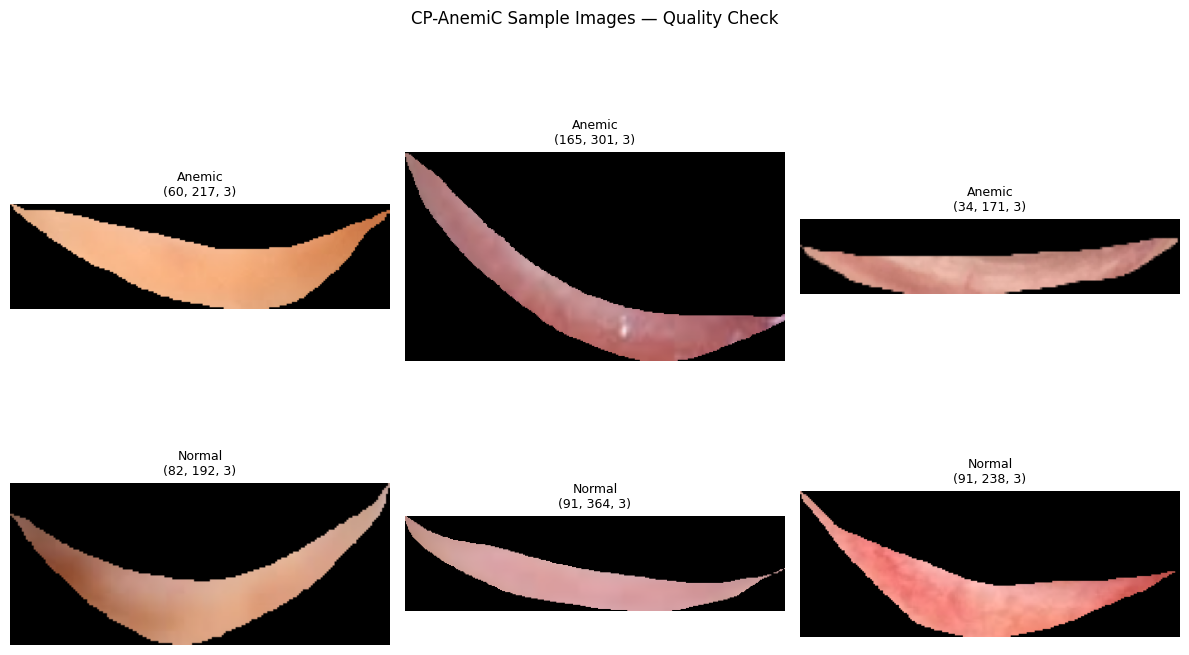


Saved: cpanemic_quality_check.png


In [ ]:
# Inspect CP-AnemiC images
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

CP_ANEMIC = '/content/cpanemic/extracted/Anemic'
CP_NORMAL = '/content/cpanemic/extracted/Non-anemic'

# Check sizes
anemic_files = os.listdir(CP_ANEMIC)[:5]
normal_files = os.listdir(CP_NORMAL)[:5]

print("CP-AnemiC image inspection:")
print()
print("ANEMIC samples:")
for f in anemic_files:
    path = os.path.join(CP_ANEMIC, f)
    img  = cv2.imread(path)
    size = os.path.getsize(path)
    if img is not None:
        print(f"  {f}: shape={img.shape}  disk={size/1024:.1f}KB")
    else:
        print(f"  {f}: COULD NOT LOAD")

print()
print("NORMAL samples:")
for f in normal_files:
    path = os.path.join(CP_NORMAL, f)
    img  = cv2.imread(path)
    size = os.path.getsize(path)
    if img is not None:
        print(f"  {f}: shape={img.shape}  disk={size/1024:.1f}KB")
    else:
        print(f"  {f}: COULD NOT LOAD")

# Show sample images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('CP-AnemiC Sample Images — Quality Check', fontsize=12)

for col, f in enumerate(anemic_files[:3]):
    img = cv2.imread(os.path.join(CP_ANEMIC, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0,col].imshow(img)
    axes[0,col].set_title(f'Anemic\n{img.shape}', fontsize=9)
    axes[0,col].axis('off')

for col, f in enumerate(normal_files[:3]):
    img = cv2.imread(os.path.join(CP_NORMAL, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1,col].imshow(img)
    axes[1,col].set_title(f'Normal\n{img.shape}', fontsize=9)
    axes[1,col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/anemia_project/cpanemic_quality_check.png',
            dpi=100, bbox_inches='tight')
plt.show()
print()
print("Saved: cpanemic_quality_check.png")

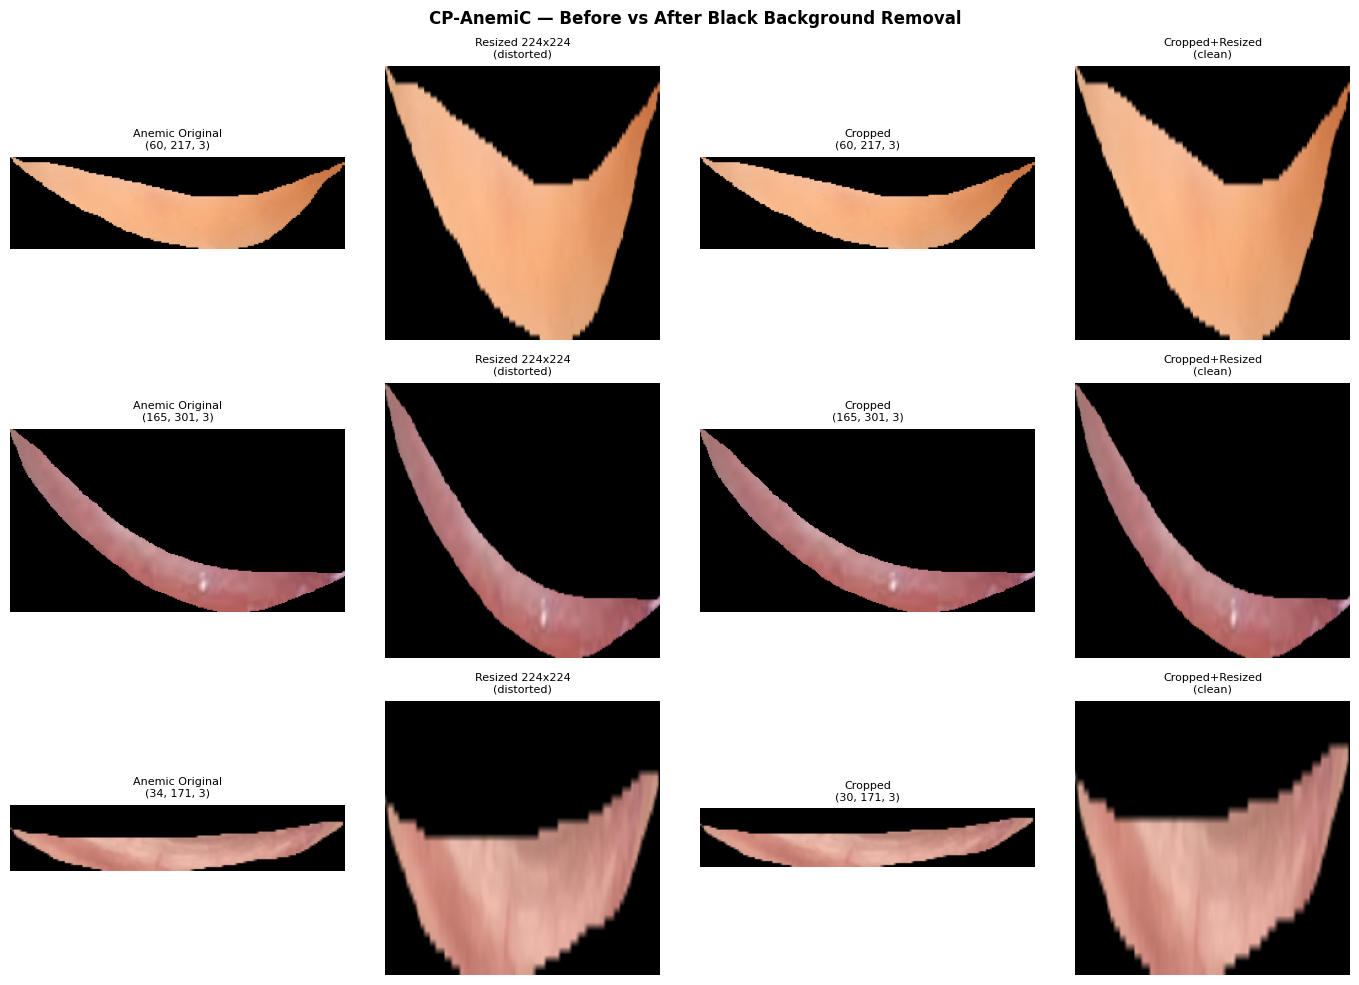

Saved: crop_comparison.png

The cropped+resized version is what we feed to MobileNetV2
This removes the black border that was confusing the model


In [ ]:
# CP-AnemiC preprocessing ,remove black background
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def crop_black_background(img):
    """
    Crop out the black border around conjunctiva.
    Returns just the tissue region.
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Threshold — anything above 15 is tissue
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    # Find bounding box of non-black region
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img  # fallback — return original

    x, y, w, h = cv2.boundingRect(coords)

    # Add small padding
    pad = 5
    x = max(0, x - pad)
    y = max(0, y - pad)
    w = min(img.shape[1] - x, w + 2*pad)
    h = min(img.shape[0] - y, h + 2*pad)

    cropped = img[y:y+h, x:x+w]
    return cropped

# Test on sample images
CP_ANEMIC = '/content/cpanemic/extracted/Anemic'
CP_NORMAL = '/content/cpanemic/extracted/Non-anemic'

sample_files = os.listdir(CP_ANEMIC)[:3] + os.listdir(CP_NORMAL)[:3]
sample_paths = [os.path.join(CP_ANEMIC, f) for f in os.listdir(CP_ANEMIC)[:3]] + \
               [os.path.join(CP_NORMAL, f) for f in os.listdir(CP_NORMAL)[:3]]
sample_labels = ['Anemic']*3 + ['Normal']*3

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('CP-AnemiC — Before vs After Black Background Removal',
             fontsize=12, fontweight='bold')

for row, (path, label) in enumerate(zip(sample_paths[:3], sample_labels[:3])):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Original resized
    orig_resized = cv2.resize(img, (224,224))

    # Cropped then resized
    cropped     = crop_black_background(img)
    crop_resized = cv2.resize(cropped, (224,224))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'{label} Original\n{img.shape}', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(orig_resized)
    axes[row, 1].set_title(f'Resized 224x224\n(distorted)', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(cropped)
    axes[row, 2].set_title(f'Cropped\n{cropped.shape}', fontsize=8)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(crop_resized)
    axes[row, 3].set_title(f'Cropped+Resized\n(clean)', fontsize=8)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/anemia_project/crop_comparison.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("Saved: crop_comparison.png")
print()
print("The cropped+resized version is what we feed to MobileNetV2")
print("This removes the black border that was confusing the model")